In [87]:
!apt-get update -q
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark kaggle --quiet
!python --version
!java -version
!pip show pyspark | grep Version

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Python 3.12.12
openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
Vers

Préparation de l’environnement


In [88]:
import os
from pyspark.sql.functions import col, when, count, regexp_replace, trim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

# Initialisation de la session Spark
spark = SparkSession.builder \
    .appName("ChurnPredictionProject") \
    .getOrCreate()

spark


Récupération du dataset

In [89]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv

--2025-12-14 09:31:17--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’

WA_Fn-UseC_-Telco-C 100%[===================>] 954.59K  5.57MB/s    in 0.2s    

2025-12-14 09:31:18 (5.57 MB/s) - ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’ saved [977501/977501]



In [90]:
! ls

sample_data  WA_Fn-UseC_-Telco-Customer-Churn.csv


In [91]:
df = spark.read.csv("WA_Fn-UseC_-Telco-Customer-Churn.csv", header=True, inferSchema=True)
df.show(5)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|            0|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|    

In [92]:
# Nombre de lignes et de colonnes
print(f"Nombre de lignes : {df.count()}")
print(f"Nombre de colonnes : {len(df.columns)}")

# Aperçu des colonnes
df.printSchema()

# Voir quelques valeurs distinctes dans certaines colonnes
df.select("gender", "Partner", "Churn").distinct().show()


Nombre de lignes : 7043
Nombre de colonnes : 21
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)

+------+-------+-----+
|gender|Pa

In [93]:
df.groupBy("Churn").count().show() # vérification pour voir le déséquilibre des classes

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5174|
|  Yes| 1869|
+-----+-----+



Nettoyage et préparation des données

In [94]:
df_str = df.select([
    col(c).cast("string").alias(c) for c in df.columns
])

In [95]:
print("Valeurs manquantes par colonne :")

df_str.select([
    count(
        when(
            col(c).isNull() | (trim(col(c)) == ""),
            c
        )
    ).alias(c)
    for c in df_str.columns
]).show(truncate=False)

Valeurs manquantes par colonne :
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|0         |0     |0            |0      |0         |0     |0           |0            |0              |0             |0           |0               |0          |0          |0         

In [96]:
# Supprimer les lignes où TotalCharges est vide ou null
df = df.filter(~(col("TotalCharges").isNull() | (trim(col("TotalCharges")) == "")))

# Vérification : compter à nouveau les valeurs manquantes dans TotalCharges
df.select(
    count(when(col("TotalCharges").isNull() | (trim(col("TotalCharges")) == ""), "TotalCharges")).alias("missing_TotalCharges")
).show()

print(f"Nombre de lignes après nettoyage : {df.count()}")


+--------------------+
|missing_TotalCharges|
+--------------------+
|                   0|
+--------------------+

Nombre de lignes après nettoyage : 7032


In [97]:
numeric_cols = ["TotalCharges"]   # Conversion du type de TotalCharges en float
df = df.withColumn("TotalCharges", col("TotalCharges").cast("float"))

In [98]:
df.printSchema()  # Aperçu des colonnes

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: float (nullable = true)
 |-- Churn: string (nullable = true)



Encodage des variables catégorielles

100 % Spark MLlib : on utilise StringIndexer + OneHotEncoder

In [99]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

# Liste des variables catégorielles (texte)
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Indexation (texte -> nombre)
indexers = [StringIndexer(inputCol=c, outputCol=c+"_indexed", handleInvalid="keep") for c in categorical_cols]

# Encodage one-hot (nombre -> vecteur binaire)
encoders = [OneHotEncoder(inputCol=c+"_indexed", outputCol=c+"_encoded") for c in categorical_cols]


Encodage de la variable cible “Churn”

On transforme Yes/No en 1/0

In [100]:
label_indexer = StringIndexer(inputCol="Churn", outputCol="label")

Assemblage des features

On crée une grande colonne features (vecteur) regroupant toutes les variables numériques + encodées.

In [101]:
from pyspark.ml.feature import VectorAssembler

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
encoded_features = [c+"_encoded" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=numeric_features + encoded_features,
    outputCol="features"
)

Construction du pipeline Spark complet

On regroupe toutes les étapes en un pipeline MLlib

In [102]:
numeric_cols = ["TotalCharges"]   # Conversion du type de TotalCharges en float
df = df.withColumn("TotalCharges", col("TotalCharges").cast("float"))

In [103]:
from pyspark.ml import Pipeline

# Définition du pipeline de transformation
pipeline = Pipeline(stages=indexers + encoders + [label_indexer, assembler])

# Exécution du pipeline
prepared_df = pipeline.fit(df).transform(df)

In [104]:
# Afficher les colonnes finales
prepared_df.printSchema()

# Voir la colonne features et label
prepared_df.select("features", "label").show(5, truncate=False)

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: float (nullable = true)
 |-- Churn: string (nullable = true)
 |-- gender_indexed: double (nullable = false)
 |-- SeniorCitizen_indexed: double (

Les données brutes sont enfin transformées en format vectorisé, que les algorithmes de machine learning de Spark peuvent comprendre.

In [105]:
# Statistiques de base sur les variables numériques
df.select("tenure", "MonthlyCharges", "TotalCharges").describe().show()

# Moyenne de MonthlyCharges par type de contrat
df.groupBy("Contract").avg("MonthlyCharges").show()

+-------+------------------+------------------+-----------------+
|summary|            tenure|    MonthlyCharges|     TotalCharges|
+-------+------------------+------------------+-----------------+
|  count|              7032|              7032|             7032|
|   mean|32.421786120591584| 64.79820819112632|2283.300441385536|
| stddev|24.545259709263245|30.085973884049825|2266.771363107635|
|    min|                 1|             18.25|             18.8|
|    max|                72|            118.75|           8684.8|
+-------+------------------+------------------+-----------------+

+--------------+-------------------+
|      Contract|avg(MonthlyCharges)|
+--------------+-------------------+
|Month-to-month|  66.39849032258037|
|      One year|  65.07941576086947|
|      Two year| 60.872373887240336|
+--------------+-------------------+



Modélisation avec MLlib

Division du dataset en Train / Test

In [106]:
# 1) Split train / test
train_df, test_df = prepared_df.select("features", "label").randomSplit([0.8, 0.2], seed=42)

print("Taille train:", train_df.count())
print("Taille test:", test_df.count())

Taille train: 5690
Taille test: 1342


In [107]:
from pyspark.ml.classification import LogisticRegression

# Création et entraînement du modèle
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=50)
lr_model = lr.fit(train_df)

# Prédictions sur le test
pred_lr = lr_model.transform(test_df)

In [108]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, maxDepth=7, seed=42)
rf_model = rf.fit(train_df)

pred_rf = rf_model.transform(test_df)

In [109]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Multiclass evaluator (accuracy, f1)
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# Binary evaluator for AUC (requires rawPrediction or probability)
binary_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# Logistic Regression metrics
print("=== Logistic Regression ===")
print("Accuracy:", evaluator_acc.evaluate(pred_lr))
print("F1:", evaluator_f1.evaluate(pred_lr))
print("Precision:", evaluator_precision.evaluate(pred_lr))
print("Recall:", evaluator_recall.evaluate(pred_lr))
print("AUC:", binary_evaluator.evaluate(pred_lr))

# Random Forest metrics
print("\n=== Random Forest ===")
print("Accuracy:", evaluator_acc.evaluate(pred_rf))
print("F1:", evaluator_f1.evaluate(pred_rf))
print("Precision:", evaluator_precision.evaluate(pred_rf))
print("Recall:", evaluator_recall.evaluate(pred_rf))
print("AUC:", binary_evaluator.evaluate(pred_rf))


=== Logistic Regression ===
Accuracy: 0.797317436661699
F1: 0.7935134512868935
Precision: 0.791325022954358
Recall: 0.797317436661699
AUC: 0.8453350101306503

=== Random Forest ===
Accuracy: 0.7950819672131147
F1: 0.7872160077687578
Precision: 0.7852571300247024
Recall: 0.7950819672131146
AUC: 0.8460434569971284


In [110]:
# Confusion matrix simple
def show_confusion(predictions):
    cm = predictions.groupBy("label", "prediction").count().orderBy("label","prediction")
    cm.show()

print("Confusion matrix - Logistic Regression")
show_confusion(pred_lr)

print("Confusion matrix - Random Forest")
show_confusion(pred_rf)

Confusion matrix - Logistic Regression
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  859|
|  0.0|       1.0|  116|
|  1.0|       0.0|  156|
|  1.0|       1.0|  211|
+-----+----------+-----+

Confusion matrix - Random Forest
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  875|
|  0.0|       1.0|  100|
|  1.0|       0.0|  175|
|  1.0|       1.0|  192|
+-----+----------+-----+



In [111]:
df.groupBy("Churn").count().show()


+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5163|
|  Yes| 1869|
+-----+-----+



In [112]:
major_count = df.filter(df.Churn == "No").count()
minor_count = df.filter(df.Churn == "Yes").count()

ratio = int(major_count / minor_count)
print("Ratio d'imbalance :", ratio)

Ratio d'imbalance : 2


In [113]:
from pyspark.sql import DataFrame

# Sépare les classes
df_major = df.filter(df.Churn == "No")
df_minor = df.filter(df.Churn == "Yes")

# Sur-échantillonnage de la classe minoritaire
df_minority_oversampled = df_minor.sample(withReplacement=True, fraction=float(ratio), seed=42)

# Fusionne les deux DataFrames
df_balanced = df_major.unionAll(df_minority_oversampled)

# Vérifie la nouvelle distribution
df_balanced.groupBy("Churn").count().show()

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5163|
|  Yes| 3726|
+-----+-----+



In [114]:
# On ajuste le pipeline sur le dataset équilibré
pipelineModel_balanced = pipeline.fit(df_balanced)

# Transformation du dataset équilibré
prepared_df_balanced = pipelineModel_balanced.transform(df_balanced)

In [115]:
# Séparation en jeu d'entraînement et de test
train_df_bal, test_df_bal = prepared_df_balanced.randomSplit([0.8, 0.2], seed=42)

print("Taille train :", train_df_bal.count())
print("Taille test :", test_df_bal.count())

Taille train : 7151
Taille test : 1738


In [116]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier

# Modèle 1 : Régression Logistique
logreg_bal = LogisticRegression(featuresCol="features", labelCol="label")
logreg_model_bal = logreg_bal.fit(train_df_bal)
pred_log_bal = logreg_model_bal.transform(test_df_bal)

# Modèle 2 : Random Forest
rf_bal = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=7)
rf_model_bal = rf_bal.fit(train_df_bal)
pred_rf_bal = rf_model_bal.transform(test_df_bal)

In [117]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="precisionByLabel")
evaluator_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="recallByLabel")
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

def eval_model(pred_df, name):
    acc = evaluator_acc.evaluate(pred_df)
    f1 = evaluator_f1.evaluate(pred_df)
    prec = evaluator_prec.evaluate(pred_df)
    rec = evaluator_rec.evaluate(pred_df)
    auc = evaluator_auc.evaluate(pred_df)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"AUC: {auc:.4f}\n")

# Évaluation
eval_model(pred_log_bal, "Logistic Regression (Balanced)")
eval_model(pred_rf_bal, "Random Forest (Balanced)")

=== Logistic Regression (Balanced) ===
Accuracy: 0.7641
F1: 0.7641
Precision: 0.7942
Recall: 0.7958
AUC: 0.8492

=== Random Forest (Balanced) ===
Accuracy: 0.7814
F1: 0.7816
Precision: 0.8149
Recall: 0.8018
AUC: 0.8614



In [118]:
pred_log_bal.groupBy("label", "prediction").count().show()
pred_rf_bal.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       1.0|  204|
|  0.0|       0.0|  795|
|  1.0|       1.0|  533|
|  1.0|       0.0|  206|
+-----+----------+-----+

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       1.0|  198|
|  0.0|       0.0|  801|
|  1.0|       1.0|  557|
|  1.0|       0.0|  182|
+-----+----------+-----+



In [119]:
# AUC avant (résultats précédents)
auc_before_lr = 0.8453
auc_before_rf = 0.8464

# AUC après
auc_after_lr = evaluator_auc.evaluate(pred_log_bal)
auc_after_rf = evaluator_auc.evaluate(pred_rf_bal)

print(f"AUC Logistic Regression - Avant: {auc_before_lr:.3f} | Après: {auc_after_lr:.3f}")
print(f"AUC Random Forest        - Avant: {auc_before_rf:.3f} | Après: {auc_after_rf:.3f}")

AUC Logistic Regression - Avant: 0.845 | Après: 0.849
AUC Random Forest        - Avant: 0.846 | Après: 0.861


In [120]:
# On recrée le pipeline entraîné et on le garde dans pipelineModel
pipelineModel = pipeline.fit(df)

In [125]:
# Récupère les étapes du pipeline ajusté
stages = pipelineModel.stages  # indexers + encoders + label_indexer + assembler

# Les indexers sont les premiers len(categorical_cols) éléments
n_indexers = len(categorical_cols)
indexer_models = stages[:n_indexers]

# Les encoders sont les suivants (même nombre)
encoder_models = stages[n_indexers:n_indexers + n_indexers]

# L'assembler est la dernière étape (ou recherche de l'assembler)
from pyspark.ml.feature import VectorAssembler
assembler_model = None
for s in stages:
    if isinstance(s, VectorAssembler):
        assembler_model = s
        break

# Numeric features (ordre que j'ai passé au VectorAssembler)
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
feature_names = []
feature_names.extend(numeric_features)

# Pour chaque encoder, retrouver les labels de l'indexer correspondant
for idx_model, enc_model in zip(indexer_models, encoder_models):
    orig_col = idx_model.getInputCol().replace("_indexed", "")  # ex: 'gender'
    labels = idx_model.labels  # labels dans l'ordre d'indexation
    # longueur de la sortie de l'encoder (dropLast=True => size = len(labels)-1)
    # OneHotEncoderModel dispose d'attribut 'categorySizes'
    cat_size = enc_model.categorySizes[0] if hasattr(enc_model, "categorySizes") and len(enc_model.categorySizes)>0 else len(labels)
    drop_last = True  # par défaut OneHotEncoder dropLast=True
    out_dim = (cat_size - 1) if drop_last else cat_size

    # On crée des noms pour chaque dimension encodée (on saute le dernier label si dropLast=True)
    n_to_make = out_dim
    for i in range(n_to_make):
        # label associé (attention : indexer.labels[i] correspond au label d'index i)
        if i < len(labels):
            fname = f"{orig_col}={labels[i]}"
        else:
            fname = f"{orig_col}_val{i}"
        feature_names.append(fname)

# Vérif : longueur doit = assembler input vector size
print("Nombre features reconstruit :", len(feature_names))
print("Feature names (extraites) :", feature_names[:30])


Nombre features reconstruit : 46
Feature names (extraites) : ['tenure', 'MonthlyCharges', 'TotalCharges', 'gender=Male', 'gender=Female', 'SeniorCitizen=0', 'SeniorCitizen=1', 'Partner=No', 'Partner=Yes', 'Dependents=No', 'Dependents=Yes', 'PhoneService=Yes', 'PhoneService=No', 'MultipleLines=No', 'MultipleLines=Yes', 'MultipleLines=No phone service', 'InternetService=Fiber optic', 'InternetService=DSL', 'InternetService=No', 'OnlineSecurity=No', 'OnlineSecurity=Yes', 'OnlineSecurity=No internet service', 'OnlineBackup=No', 'OnlineBackup=Yes', 'OnlineBackup=No internet service', 'DeviceProtection=No', 'DeviceProtection=Yes', 'DeviceProtection=No internet service', 'TechSupport=No', 'TechSupport=Yes']


In [122]:
# Récupérer les importances depuis le modèle RF
importances = rf_model.featureImportances  # vecteur sparse Dense/SparseVector

# Transformer en liste (dense) et associer aux noms
imp_list = list(importances.toArray())

# Associer noms -> importance
feat_imp = list(zip(feature_names, imp_list))

# Trier par importance décroissante
feat_imp_sorted = sorted(feat_imp, key=lambda x: x[1], reverse=True)

# Afficher top 20
print("Top 20 features by importance:")
for name, imp in feat_imp_sorted[:20]:
    print(f"{name:40s} -> {imp:.5f}")

Top 20 features by importance:
Contract=Month-to-month                  -> 0.16734
tenure                                   -> 0.14555
TotalCharges                             -> 0.07662
OnlineSecurity=No                        -> 0.07365
TechSupport=No                           -> 0.06675
InternetService=Fiber optic              -> 0.06645
Contract=Two year                        -> 0.05930
PaymentMethod=Electronic check           -> 0.05018
MonthlyCharges                           -> 0.04646
OnlineBackup=No                          -> 0.02654
InternetService=DSL                      -> 0.02550
Contract=One year                        -> 0.01789
DeviceProtection=No                      -> 0.01453
TechSupport=Yes                          -> 0.01419
OnlineSecurity=Yes                       -> 0.01372
PaperlessBilling=No                      -> 0.00929
StreamingMovies=No internet service      -> 0.00868
TechSupport=No internet service          -> 0.00832
PaperlessBilling=Yes             

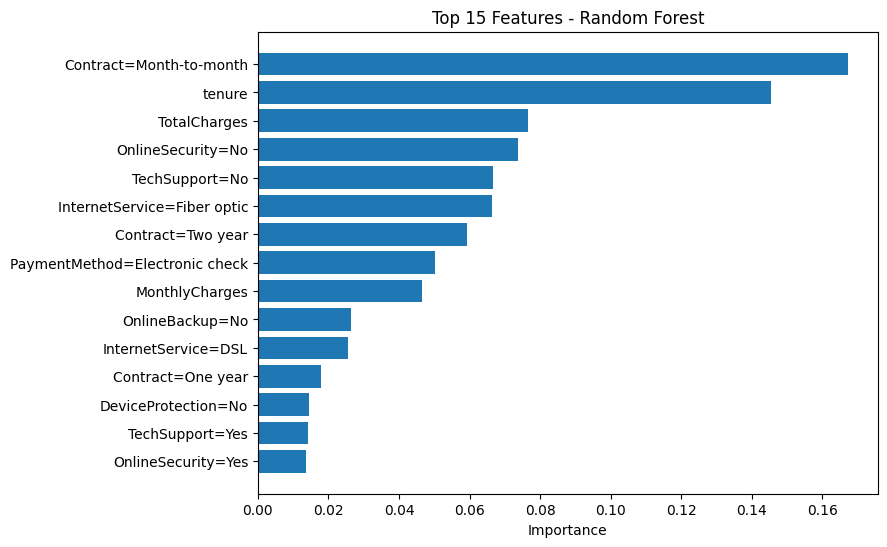

In [123]:
import matplotlib.pyplot as plt

names = [x[0] for x in feat_imp_sorted[:15]]
values = [x[1] for x in feat_imp_sorted[:15]]

plt.figure(figsize=(8,6))
plt.barh(names[::-1], values[::-1])
plt.xlabel("Importance")
plt.title("Top 15 Features - Random Forest")
plt.show()

In [124]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Grid
paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [50, 100])
             .addGrid(rf.maxDepth, [5, 7])
             .build())

# Cross-validator (ici 3-fold pour rapidité)
cv = CrossValidator(estimator=rf,
                    estimatorParamMaps=paramGrid,
                    evaluator=binary_evaluator,
                    numFolds=3,
                    parallelism=2)  # parallélisme pour accélérer si possible

cv_model = cv.fit(train_df)

# Meilleur modèle
best_rf = cv_model.bestModel
print("Meilleurs params:", {p.name: best_rf.getOrDefault(p) for p in [rf.numTrees, rf.maxDepth]})

# Évaluer sur test
pred_cv = best_rf.transform(test_df)
print("AUC (best RF):", binary_evaluator.evaluate(pred_cv))
print("Accuracy (best RF):", evaluator_acc.evaluate(pred_cv))

Meilleurs params: {'numTrees': 100, 'maxDepth': 7}
AUC (best RF): 0.8460434569971284
Accuracy (best RF): 0.7950819672131147
